# Visualizing Tensor Accesses Over Time

This notebook shows a visualization of the order in which tensor elements are accessed from a LoopTree.

## An unfused mapping

We start with a chain of matrix multiplications, 
mapped onto the simple architecture without fusion.

In [1]:
import accelforge as af

spec = af.Spec.from_yaml(
    af.examples.arches.simple,
    af.examples.workloads.basic.matmuls,
    af.examples.mappings.unfused_matmuls_to_simple,
    jinja_parse_data={"N_EINSUMS": 2, "M": 4, "KN": 3},
)
results = spec.evaluate_mapping()

The architecture is a simple one, with just MainMemory, GlobalBuffer, and a MAC.

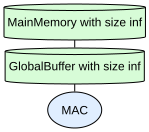

In [2]:
spec.arch

The mapping, in LoopTree notation, is shown below:

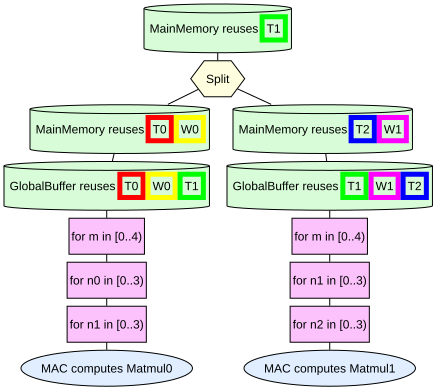

In [3]:
results.render(with_tile_shape=False, with_reservations=False)

Below, `plot_access_trace` visualizes which element is accessed at each timestep.
Different colors show different Einsums.

(<Figure size 650x1060 with 5 Axes>,
 [<Axes: title={'left': 'T0  [4x3]'}, ylabel='Element'>,
  <Axes: title={'left': 'W0  [3x3]'}, ylabel='Element'>,
  <Axes: title={'left': 'T1  [4x3]'}, ylabel='Element'>,
  <Axes: title={'left': 'W1  [3x3]'}, ylabel='Element'>,
  <Axes: title={'left': 'T2  [4x3]'}, xlabel='Timestep', ylabel='Element'>])

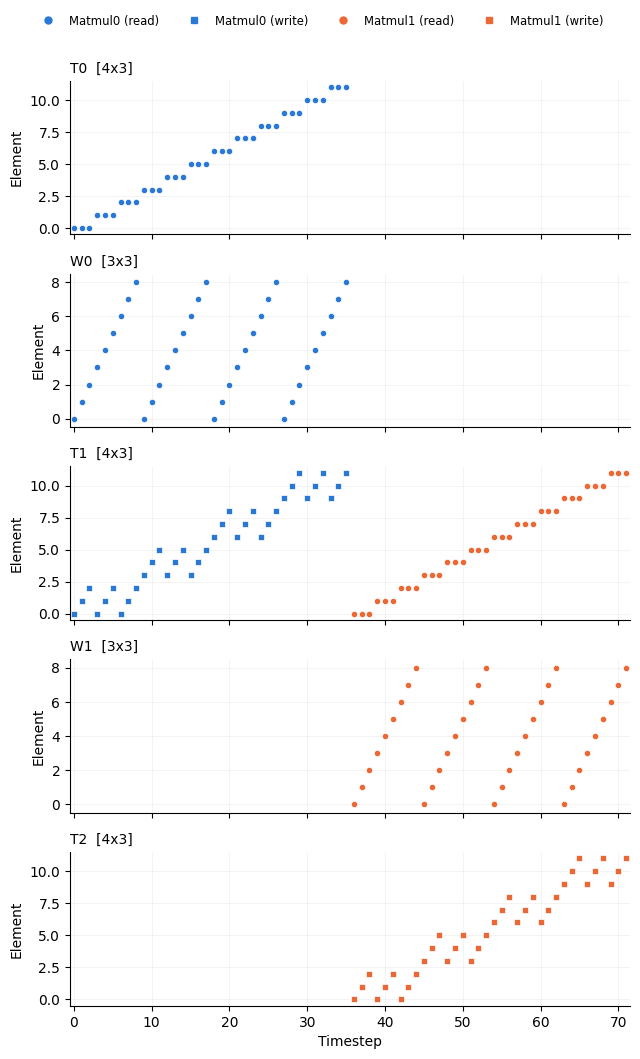

In [4]:
from accelforge.plotting import plot_access_trace

plot_access_trace(spec)

Reading the plot from the top:

- **T0** is repeatedly accessed one at a time because the `m` loop is outermost. That is, the dataflow is **T0** stationary.
- **W0** is accessed from the first to last element (*i.e.*, *scanned*) for each iteration of `m` and `n0`.
- **T1** is written by `Matmul0` in the first half of the timesteps and read by
  `Matmul1` in the second half. **T1** is *tile stationary* in Matmul0 and stationary in Matmul1.
- **W1** is scanned repeatedly like **W0**.
- **T2** is tile stationary in Matmul1.

Note how the entirety of **T1** is produced before any of it is consumed.

## Tiled, Fused Mapping

Now, we study a mapping that produces and consumes **T1** one tile at a time.

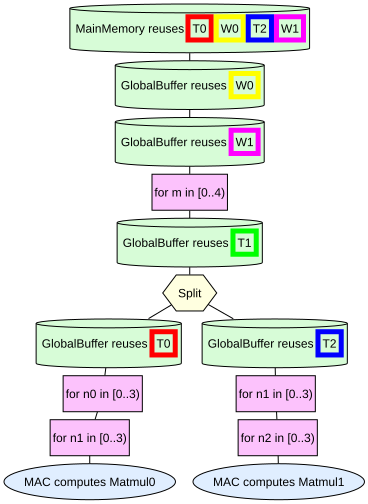

In [5]:
fused = af.Spec.from_yaml(
    af.examples.arches.simple,
    af.examples.workloads.basic.matmuls,
    af.examples.mappings.fused_matmuls_to_simple,
    jinja_parse_data={"N_EINSUMS": 2, "M": 4, "KN": 3},
)
fused_results = fused.evaluate_mapping()
fused_results.render(with_tile_shape=False, with_reservations=False)

(<Figure size 650x1060 with 5 Axes>,
 [<Axes: title={'left': 'T0  [4x3]'}, ylabel='Element'>,
  <Axes: title={'left': 'W0  [3x3]'}, ylabel='Element'>,
  <Axes: title={'left': 'T1  [4x3]'}, ylabel='Element'>,
  <Axes: title={'left': 'W1  [3x3]'}, ylabel='Element'>,
  <Axes: title={'left': 'T2  [4x3]'}, xlabel='Timestep', ylabel='Element'>])

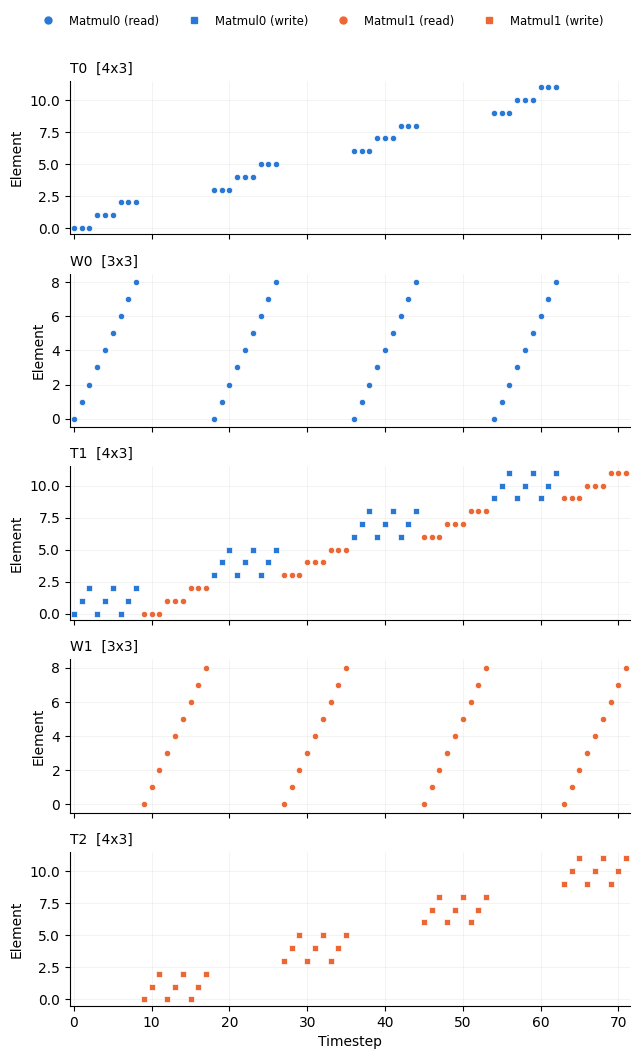

In [6]:
plot_access_trace(fused)

## Visualizing Tiles in Memory

The points show accessed tensor elements; If `memory_level` parameter is set, then the tensor
elements in the in-memory tile is shaded.

(<Figure size 650x1060 with 5 Axes>,
 [<Axes: title={'left': 'T0  [4x3]'}, ylabel='Element'>,
  <Axes: title={'left': 'W0  [3x3]'}, ylabel='Element'>,
  <Axes: title={'left': 'T1  [4x3]'}, ylabel='Element'>,
  <Axes: title={'left': 'W1  [3x3]'}, ylabel='Element'>,
  <Axes: title={'left': 'T2  [4x3]'}, xlabel='Timestep', ylabel='Element'>])

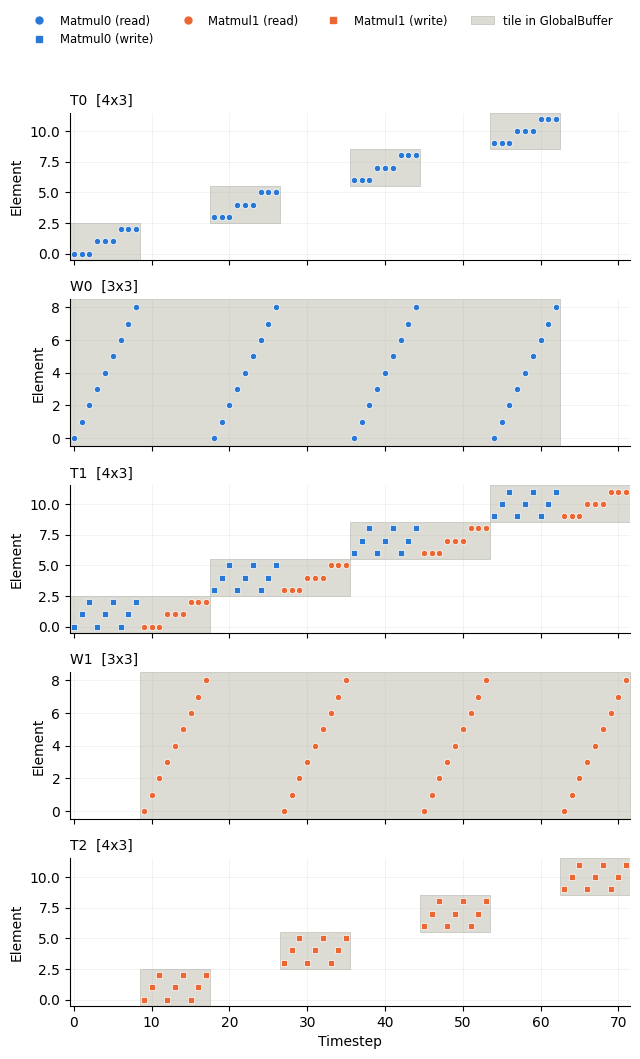

In [7]:
plot_access_trace(fused, memory_level="GlobalBuffer")


The **W0** and **W1** tiles live the entire time because their
`GlobalBuffer` storage sits above the `m` loop so the weights are
fetched once and reused.

On the other hand, **T0**, **T1**, and **T2** fetch a new tile per
iteration of `m`.